In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import os

print(os.getcwd())

c:\Users\zakiy\Downloads\archive\customer_behavior_analysis


In [6]:
df = pd.read_csv("../ecommerce_customer_data_custom_ratios.csv")

print(df.shape)
df.head()

(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
Customer ID              250000 non-null int64
Purchase Date            250000 non-null object
Product Category         250000 non-null object
Product Price            250000 non-null int64
Quantity                 250000 non-null int64
Total Purchase Amount    250000 non-null int64
Payment Method           250000 non-null object
Customer Age             250000 non-null int64
Returns                  202404 non-null float64
Customer Name            250000 non-null object
Age                      250000 non-null int64
Gender                   250000 non-null object
Churn                    250000 non-null int64
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [8]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [9]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [10]:
df["Churn"].value_counts()

0    200126
1     49874
Name: Churn, dtype: int64

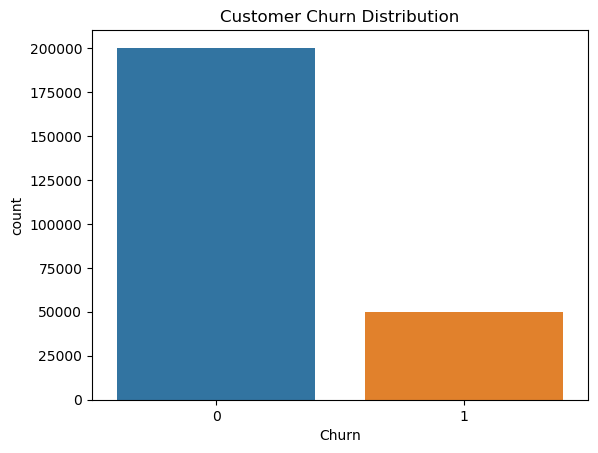

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

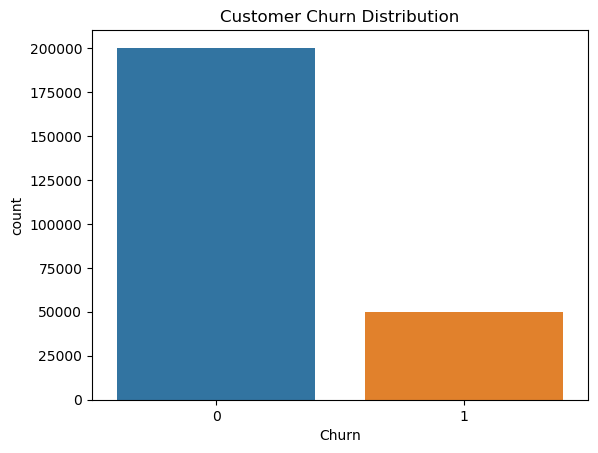

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Customer Age Distribution")
plt.show()

AttributeError: module 'seaborn' has no attribute 'histplot'

<Figure size 800x500 with 0 Axes>

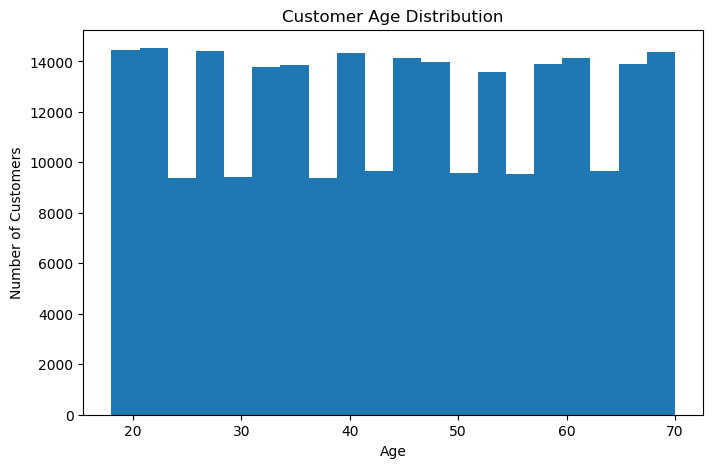

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Product Category
Books          204939601
Clothing       204532405
Electronics    136599467
Home           135271210
Name: Total Purchase Amount, dtype: int64


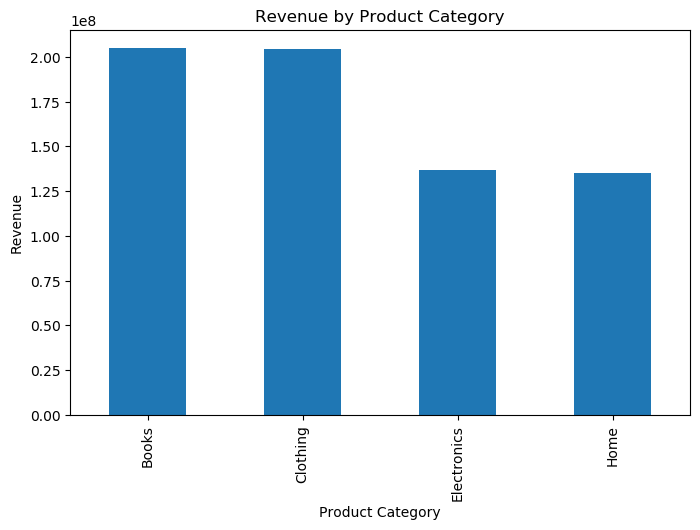

In [15]:
category_sales = df.groupby("Product Category")["Total Purchase Amount"].sum()

print(category_sales)

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

Credit Card    100486
PayPal          74837
Cash            49894
Crypto          24783
Name: Payment Method, dtype: int64


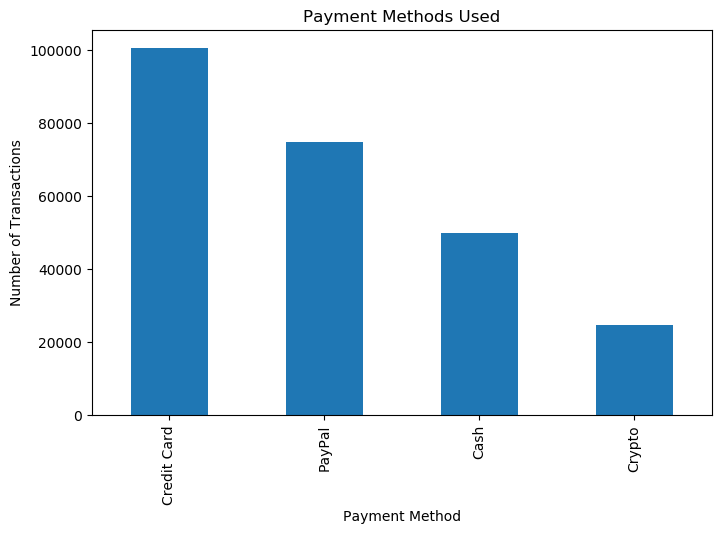

In [16]:
payment_counts = df["Payment Method"].value_counts()

print(payment_counts)

payment_counts.plot(kind="bar", figsize=(8,5))

plt.title("Payment Methods Used")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

In [17]:
churn_category = pd.crosstab(
    df["Product Category"],
    df["Churn"]
)

print(churn_category)

Churn                 0      1
Product Category              
Books             59986  14926
Clothing          60154  14898
Electronics       40206   9979
Home              39780  10071
